In [44]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/digit-recognizer/sample_submission.csv
/kaggle/input/competitions/digit-recognizer/train.csv
/kaggle/input/competitions/digit-recognizer/test.csv


In [45]:
df = pd.read_csv('/kaggle/input/competitions/digit-recognizer/train.csv')
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [46]:
df.shape

(42000, 785)

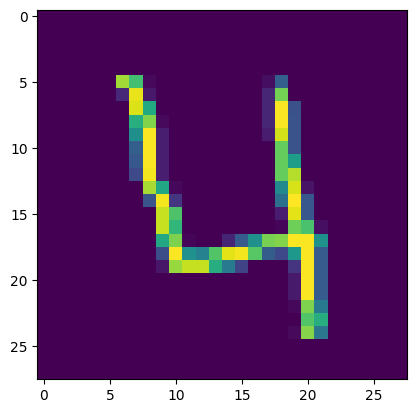

In [47]:
import matplotlib.pyplot as plt

plt.imshow(df.iloc[3,1:].values.reshape(28,28))

In [48]:
X = df.iloc[:,1:]
y = df.iloc[:,1]


In [49]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [50]:
X_train.shape

(33600, 784)

In [51]:
from sklearn.neighbors import KNeighborsClassifier

In [52]:
knn = KNeighborsClassifier()
knn.fit(X_train,Y_train)



KNeighborsClassifier()

In [53]:
import time
start = time.time()
prediction = knn.predict(X_test)
end = time.time()
print(end-start)

10.263581991195679


In [54]:
from sklearn.metrics import accuracy_score

In [55]:
accuracy_score(Y_test,prediction)

1.0

PCA

In [56]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [57]:
# PCA
from sklearn.decomposition import PCA

pca = PCA(n_components = 100)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [58]:
X_train.shape

(33600, 784)

In [59]:
X_train_trf.shape

(33600, 100)

In [61]:
knn = KNeighborsClassifier()
X_train_trf = knn.fit(X_train_trf,Y_train)
prediction = knn.predict(X_test_trf)
accuracy_score(Y_test,prediction)

1.0

In [63]:
pca = PCA(n_components = 2)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)
X_train_trf.shape

(33600, 2)

In [68]:
import plotly.express as px
Y_train_trf = Y_train.astype(str)
fig = px.scatter(x=X_train_trf[:,0],
                 y=X_train_trf[:,1],
                 color = Y_train_trf,
                 color_discrete_sequence=px.colors.qualitative.G10,
                )
fig.show()

In [70]:
pca = PCA(n_components = 3)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)
X_train_trf.shape

(33600, 3)

In [79]:
import plotly.express as px
Y_train_trf = Y_train.values.astype(str)
fig = px.scatter_3d(x=X_train_trf[:,0],
                 y=X_train_trf[:,1],
                 z=X_train_trf[:,2],
                 color = Y_train_trf,
                 color_discrete_sequence=px.colors.qualitative.G10,
                )
fig.show()

In [83]:
pca.components_.shape

(3, 784)

In [86]:
pca.explained_variance_

array([40.67111198, 29.17023401, 26.74459621])

In [88]:
pca.explained_variance_ratio_

array([0.05785192, 0.0414927 , 0.03804239])

In [89]:
pca = PCA(n_components = None)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)
X_train_trf.shape

(33600, 784)

In [91]:
pca.explained_variance_.shape

(784,)

In [94]:
pca.components_.shape

(784, 784)

In [97]:
np.cumsum(pca.explained_variance_)

array([ 40.67111198,  69.84134599,  96.5859422 , 117.43939011,
       135.5883089 , 151.4412914 , 165.31237241, 177.79296209,
       188.82090444, 198.91672978, 208.54990799, 217.17776744,
       225.24079875, 233.13591624, 240.57759553, 247.74792426,
       254.48058799, 261.10802821, 267.52301982, 273.78110251,
       279.68605993, 285.45127578, 290.9721218 , 296.29216027,
       301.47525952, 306.40965549, 311.3161772 , 316.03418213,
       320.53242657, 324.96382961, 329.28987483, 333.52479314,
       337.62814328, 341.69545508, 345.71907686, 349.5603816 ,
       353.37924306, 357.09240803, 360.70158911, 364.17462125,
       367.60305114, 370.99146273, 374.28303784, 377.51231163,
       380.72976305, 383.88786676, 387.01407582, 390.11819967,
       393.17712762, 396.2144095 , 399.17981411, 402.1201508 ,
       404.98843644, 407.8146151 , 410.61499951, 413.38911172,
       416.1089001 , 418.80284241, 421.45008611, 424.08074448,
       426.64573146, 429.18224881, 431.67014464, 434.11